In [1]:

# installo HGQ2 , inizialmente dava problemi perchè andava in conflitto con le versioni più recenti di Tensorflow. Cosi sembra funzionare.

# !pip install HGQ2   # deja installe dans l env conda local

In [2]:
# ================================================================
# CONFIGURATION LOCALE  (remplace le montage Google Drive de Colab)
# A EXECUTER EN PREMIER : ces variables doivent etre posees AVANT
# le premier import de jax / keras (cellule suivante), sinon elles
# sont ignorees.
# ================================================================
import os

# --- Backend Keras -------------------------------------------------
# Sans cela Keras 3 tente TensorFlow par defaut et leve
# ModuleNotFoundError: No module named 'tensorflow'.
os.environ.setdefault("KERAS_BACKEND", "jax")

# --- Memoire GPU ---------------------------------------------------
# Par defaut JAX prealloue ~75 % de la VRAM d'un coup. Sur une RTX 4070
# Laptop (8 Go partages avec l'affichage Windows sous WSL2) cette
# preallocation echoue et retombe en cascade avec des
# CUDA_ERROR_OUT_OF_MEMORY. On alloue a la demande a la place.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

# --- Racine des donnees --------------------------------------------
# Defaut : dossier synchronise par Google Drive, vu depuis WSL2.
# Pour pointer ailleurs (copie ext4 locale) :
#     export DRICH_DATA_ROOT=$HOME/drich_data/
DATA_ROOT = os.environ.get(
    "DRICH_DATA_ROOT",
    "/mnt/c/Users/maxim/Desktop/project_files/",
)
if not DATA_ROOT.endswith("/"):
    DATA_ROOT += "/"

assert os.path.isdir(DATA_ROOT), f"DATA_ROOT introuvable : {DATA_ROOT}"
print("DATA_ROOT      =", DATA_ROOT)
print("KERAS_BACKEND  =", os.environ["KERAS_BACKEND"])
print("prealloc XLA   =", os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"])

# --- Verbosite des logs XLA/C++ -------------------------------------
# Sous WSL2 le GPU est partage avec le compositeur Windows : l'autotuning
# XLA n'arrive pas toujours a chronometrer ses kernels candidats et emet
# "Delay kernel timed out: measured time has sub-optimal accuracy".
# C'est un message d'autotuning, pas une erreur de calcul. Decommente
# pour les faire taire (masque aussi les vraies erreurs C++) :
# os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")


DATA_ROOT      = /mnt/c/Users/maxim/Desktop/project_files/
KERAS_BACKEND  = jax
prealloc XLA   = false


In [3]:
import os
import random
import importlib
importlib.invalidate_caches()
# JAX runs the fastest for hgq in general based on our experience
# If you don't have jax, or if you want to use another backend, you can change this to 'tensorflow' or 'torch'
os.environ['KERAS_BACKEND'] = 'jax'
# tested for tensorflow, jax, and torch.
# For the best performance, we recommend using jax, or tensorflow with XLA (jit compile) enabled.
# Jit compilation for torch (torch dynamo) is not supported yet (may or may not work)

import keras
import numpy as np
from matplotlib import pyplot as plt

from hgq.layers import QConv2D, QDense, QMaxPool2D
from hgq.config import LayerConfigScope, QuantizerConfigScope
from hgq.config import QuantizerConfig, QuantizerConfigScope
from hgq.layers import QDense, QSoftmax
from hgq.utils.sugar import FreeEBOPs, PBar, BetaScheduler, ParetoFront

from keras.layers import *
from keras.models import Sequential, Model
from keras.optimizers import Adam, RMSprop

import pickle as pkl
from pathlib import Path

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Precision numerique -------------------------------------------
# mixed_float16 accelere les gros modeles, mais HGQ2 emule de l'arithmetique
# a virgule fixe : les arrondis float16 (10 bits de mantisse) peuvent fausser
# la quantification et casser l'equivalence bit a bit avec hls4ml.
# Ce modele est petit, le gain de vitesse est negligeable.
from keras import mixed_precision
USE_MIXED_PRECISION = False
mixed_precision.set_global_policy('mixed_float16' if USE_MIXED_PRECISION else 'float32')
print("dtype policy :", mixed_precision.global_policy())


dtype policy : <DTypePolicy "float32">


In [4]:
# ================================================================
# DIAGNOSTIC MATERIEL — verifie qu'on calcule bien sur le GPU
# ================================================================
import os, platform, time
import jax, jax.numpy as jnp
import keras

print("=== Backends ===")
print("  Keras backend  :", keras.backend.backend())
print("  JAX backend    :", jax.default_backend())
print("  dtype policy   :", keras.mixed_precision.global_policy())
print("  prealloc XLA   :", os.environ.get("XLA_PYTHON_CLIENT_PREALLOCATE", "<defaut: true>"))

print("\n=== Devices vus par JAX ===")
for d in jax.devices():
    print(f"  {d}  kind={d.device_kind}  platform={d.platform}")
    try:
        ms = d.memory_stats()
        print(f"      VRAM limite {ms.get('bytes_limit',0)/1e9:.2f} Go"
              f" | en usage {ms.get('bytes_in_use',0)/1e9:.2f} Go")
    except Exception:
        pass

print("\n=== CPU / RAM ===")
print("  coeurs logiques :", os.cpu_count())
print("  plateforme      :", platform.platform())
try:
    with open("/proc/meminfo") as f:
        print(f"  RAM vue par WSL : {int(f.readline().split()[1])/1e6:.1f} Go")
except Exception:
    pass

print("\n=== Ou vivent reellement les tenseurs ? ===")
x = jnp.ones((2048, 2048), jnp.float32)
print("  tenseur JAX sur :", list(x.devices()))
jax.block_until_ready(x @ x)
t0 = time.perf_counter()
for _ in range(5):
    y = x @ x
jax.block_until_ready(y)
dt = (time.perf_counter() - t0) / 5
print(f"  matmul 2048^3   : {dt*1e3:.2f} ms  ->  {2*2048**3/dt/1e12:.2f} TFLOP/s")

if jax.default_backend() != "gpu":
    print("\n!! ON CALCULE SUR CPU. Inutile de continuer :")
    print("   verifie nvidia-smi dans WSL et l'installation de jax[cuda12].")
else:
    print("\n=> OK : entrainement sur GPU.")


=== Backends ===
  Keras backend  : jax
  JAX backend    : gpu
  dtype policy   : <DTypePolicy "float32">
  prealloc XLA   : false

=== Devices vus par JAX ===
  cuda:0  kind=NVIDIA GeForce RTX 4070 Laptop GPU  platform=gpu
      VRAM limite 6.44 Go | en usage 0.00 Go

=== CPU / RAM ===
  coeurs logiques : 32
  plateforme      : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
  RAM vue par WSL : 16.0 Go

=== Ou vivent reellement les tenseurs ? ===
  tenseur JAX sur : [CudaDevice(id=0)]
  matmul 2048^3   : 1.17 ms  ->  14.65 TFLOP/s

=> OK : entrainement sur GPU.


In [5]:
FREQ = 300

In [6]:
help(QDense)

Help on class QDense in module hgq.layers.core.dense:

class QDense(hgq.layers.core.base.QLayerBaseSingleInput, keras.src.layers.core.dense.Dense)
 |  QDense(*args, **kwargs)
 |  
 |  Method resolution order:
 |      QDense
 |      hgq.layers.core.base.QLayerBaseSingleInput
 |      hgq.layers.core.base.QLayerBase
 |      keras.src.layers.core.dense.Dense
 |      keras.src.layers.layer.Layer
 |      keras.src.backend.jax.layer.JaxLayer
 |      keras.src.ops.operation.Operation
 |      keras.src.saving.keras_saveable.KerasSaveable
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, units, activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, kq_conf: None | hgq.quantizer.config.QuantizerConfig = None, iq_conf: None | hgq.quantizer.config.QuantizerConfig = None, bq_conf: None | hgq.quantizer.config.Quan

In [7]:
help(input)

Help on method raw_input in module ipykernel.kernelbase:

raw_input(prompt='') method of ipykernel.ipkernel.IPythonKernel instance
    Forward raw_input to frontends
    
    Raises
    ------
    StdinNotImplementedError if active frontend doesn't support stdin.



In [8]:
# ================================================================
# GÉOMÉTRIE : fonctions copiées de cellmap_visualizer
# (à lancer une seule fois après le chargement du drive)
# ================================================================
import pandas as pd

df_cellmap = pd.read_csv(f"{DATA_ROOT}cellmap.csv")

def rank_bin(values, n_bins):
    order = np.argsort(np.argsort(values))
    n = len(values)
    return np.minimum((order * n_bins) // n, n_bins - 1)

DAM_SHAPES = {0: (21, 3), 1: (21, 3), 2: (21, 3), 3: (17, 4), 4: (17, 4)}

def build_dam_grid_lookup_v7(df_cellmap, dam_shapes):
    """
    Le résultat lookup[(sec, n)] est un dictionnaire {(gx,gy): [canaux...]},
    et shapes_used[(sec, n)] mémorise (n_rows, n_cols).
    """
    lookup = {}
    shapes_used = {}
    for sec in range(6):
        sec_df = df_cellmap[df_cellmap["sector"] == sec].copy()
        sec_df["subsec"] = sec_df["pdu"] // 42
        sec_df["subpdu"] = sec_df["pdu"] % 42
        for n in range(5):
            n_rows, n_cols = dam_shapes[n]
            sub = sec_df[sec_df["subsec"] == n]
            centroids = sub.groupby("subpdu")[["lx", "ly"]].mean().reset_index()
            subpdu = centroids["subpdu"].astype(int).values
            pts = centroids[["lx", "ly"]].values
            pts_c = pts - pts.mean(axis=0)
            cov = np.cov(pts_c.T)
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = np.argsort(eigvals)[::-1]
            eigvecs = eigvecs[:, order]
            proj = pts_c @ eigvecs
            gx = rank_bin(proj[:, 0], n_rows)
            gy = rank_bin(proj[:, 1], n_cols)
            cell_map = {}
            for i, ch in enumerate(subpdu):
                cell_map.setdefault((int(gx[i]), int(gy[i])), []).append(ch)
            lookup[(sec, n)] = cell_map
            shapes_used[(sec, n)] = (n_rows, n_cols)
    return lookup, shapes_used

lookup, shapes_used = build_dam_grid_lookup_v7(df_cellmap, DAM_SHAPES)
print("Lookup OK — shapes_used exemple:", shapes_used[(0,0)], shapes_used[(0,3)])

Lookup OK — shapes_used exemple: (21, 3) (17, 4)


In [9]:
USE_3FEAT = True        # True = 3 features, False = 4 bins

if USE_3FEAT:
    N_BINS, SUFFIXE, SOUS_DOSSIER = 3, "3feat",       "input_time_3feat"
else:
    N_BINS, SUFFIXE, SOUS_DOSSIER = 4, "timingaware", "input_time_4bins"

path = f"{DATA_ROOT}{SOUS_DOSSIER}/"

if os.path.exists(path):
    print("Folder found! Files inside:")
    print(os.listdir(path))
else:
    print("The system cannot find the path specified. Check your folder names!")

Folder found! Files inside:
['noise_data_150kHz_3feat.npy', 'noise_data_225kHz_3feat.npy', 'noise_data_300kHz_3feat.npy', 'signal_data_150kHz_3feat.npy', 'signal_data_225kHz_3feat.npy', 'signal_data_300kHz_3feat.npy']


In [10]:
# ================================================================
# CHARGEMENT DES DONNÉES TIMINGAWARE + PROJECTION SUR LA GRILLE CNN
# ================================================================

def training_testing_data_split_ALCOR_optimized(
    random_state=42,
    signal_data="../training_datasets/20250107_input_signal_10kHzNoise_0to100.npy",
    noise_data="../training_datasets/20250107_input_noise_10kHzNoise_0to100.npy",
    dtype=np.float32,
    use_mmap=True,          # True par défaut : ne coûte jamais plus cher que False
    max_samples=None        # nouveau : plafond d'événements par classe
):
    mmap_mode = 'r' if use_mmap else None
    signal_mmap = np.load(signal_data, mmap_mode=mmap_mode)
    noise_mmap  = np.load(noise_data,  mmap_mode=mmap_mode)

    available_samples = min(len(signal_mmap), len(noise_mmap))
    n_samples = min(available_samples, max_samples) if max_samples is not None else available_samples
    print(f"Chargement de {n_samples} événements par classe (total: {n_samples*2})...")

    # slice AVANT le cast dtype -> seule la portion utile est matérialisée en RAM
    signal_inputs = signal_mmap[:n_samples].astype(dtype)
    noise_inputs  = noise_mmap[:n_samples].astype(dtype)

    X_total = np.concatenate((noise_inputs, signal_inputs), axis=0)
    y_noise  = np.zeros(len(noise_inputs), dtype=dtype)
    y_signal = np.ones(len(signal_inputs), dtype=dtype)
    y_total  = np.concatenate((y_noise, y_signal), axis=0)
    index_total = np.arange(len(y_total))

    X_train, X_tmp, y_train, y_tmp, idx_train, idx_tmp = train_test_split(
        X_total, y_total, index_total, test_size=0.2, random_state=random_state, shuffle=True)
    X_test, X_val, y_test, y_val, idx_test, idx_val = train_test_split(
        X_tmp, y_tmp, idx_tmp, test_size=0.5, random_state=random_state, shuffle=True)

    return X_train, X_val, X_test, y_train, y_val, y_test, idx_train, idx_val, idx_test

def scatter_dam_to_grid_timing(X_dam_timing, cell_map, shape, n_channels=4):
    """
    X_dam_timing : (N, 42, n_channels) — 42 PDUs × n_channels bins temporels
    Retourne     : (N, n_rows, n_cols, n_channels)
    """
    n_rows, n_cols = shape
    N = X_dam_timing.shape[0]
    img = np.zeros((N, n_rows, n_cols, n_channels), dtype=np.float32)
    for (gx, gy), chans in cell_map.items():
        # Sommer les contributions de tous les canaux qui partagent cette case
        img[:, gx, gy, :] += X_dam_timing[:, chans, :].sum(axis=1)
    return img

def build_cnn_inputs(X, lookup, shapes_used, n_channels=4):
    """
    X : (N, 30, 42*n_channels) — aplati tel que sorti du .npy
     ou (N, 30, 42, n_channels) — déjà reshapé
    Retourne : liste de 30 tenseurs (N, n_rows, n_cols, n_channels)
    """
    # Désaplatir si nécessaire
    if X.ndim == 3:
        N, n_dam, flat = X.shape
        assert flat == 42 * n_channels, \
            f"Dimension inattendue : {flat} ≠ 42×{n_channels}={42*n_channels}. " \
            f"Vérifie n_channels ou la shape du .npy."
        X = X.reshape(N, n_dam, 42, n_channels)

    N = X.shape[0]
    grids = []
    for sec in range(6):
        for n in range(5):
            dam_idx = sec * 5 + n
            cell_map = lookup[(sec, n)]
            n_rows, n_cols = shapes_used[(sec, n)]
            X_dam = X[:, dam_idx, :, :]   # (N, 42, n_channels)
            img = np.zeros((N, n_rows, n_cols, n_channels), dtype=np.float32)
            for (gx, gy), chans in cell_map.items():
                img[:, gx, gy, :] += X_dam[:, chans, :].sum(axis=1)
            grids.append(img)
    return grids

target_dir = f"{DATA_ROOT}{SOUS_DOSSIER}/"

X_train, X_val, X_test, y_train, y_val, y_test, index_train, index_val, index_test = \
    training_testing_data_split_ALCOR_optimized(
        random_state=69,
        signal_data=f"{target_dir}signal_data_{FREQ}kHz_{SUFFIXE}.npy",
        noise_data =f"{target_dir}noise_data_{FREQ}kHz_{SUFFIXE}.npy"
    )


print("Shape brute chargée :", X_train.shape)

# Si le .npy est aplati (N, 30, 168) :
X_train = X_train.reshape(X_train.shape[0], 30, 42, N_BINS)
X_test  = X_test.reshape(X_test.shape[0],   30, 42, N_BINS)
X_val   = X_val.reshape(X_val.shape[0],     30, 42, N_BINS)

print("Shape finale :", X_train.shape)
N_CHANNELS = X_train.shape[-1]   # = 3
print(f"N_CHANNELS={N_CHANNELS}")

Chargement de 79000 événements par classe (total: 158000)...
Shape brute chargée : (126400, 30, 126)
Shape finale : (126400, 30, 42, 3)
N_CHANNELS=3


In [11]:

# --- Projection sur grilles CNN ---
print("Projection sur grilles CNN...")
model_input_train = build_cnn_inputs(X_train, lookup, shapes_used, n_channels=N_CHANNELS)
model_input_test  = build_cnn_inputs(X_test,  lookup, shapes_used, n_channels=N_CHANNELS)
model_input_val   = build_cnn_inputs(X_val,   lookup, shapes_used, n_channels=N_CHANNELS)

print(f"model_input_train[0].shape  (DAM 0,  21×3×3) : {model_input_train[0].shape}")
print(f"model_input_test[14].shape (DAM 14, 17×4×3) : {model_input_test[14].shape}")
# Attendu :
# model_input_train[0].shape  → (N, 21, 3, 3)
# model_input_train[14].shape → (N, 17, 4, 3)  (DAM n=5 du secteur 3)

Projection sur grilles CNN...
model_input_train[0].shape  (DAM 0,  21×3×3) : (126400, 21, 3, 3)
model_input_test[14].shape (DAM 14, 17×4×3) : (15800, 17, 4, 3)


In [12]:
from keras.regularizers import l2

try:
    from hgq.layers import QBatchNormalization as BN
except ImportError:
    from keras.layers import BatchNormalization as BN

PARTAGE_POIDS = False     # 5 DAM au lieu de 30, 1 MLP secteur au lieu de 6

def Keras_MLP_damI(string, l2_reg=1e-4):

    inTnsr  = Input(shape=(42,), name="input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

    #x = Dense(64, name =string+'fc3')(inTnsr)
    #x = Activation("relu", name=string+'act3') (x)

    x = QDense(32, name ='fc4_'+string, activation='relu', kernel_regularizer=l2(l2_reg))(inTnsr)
    #x = Activation("relu", name='act4_'+string) (x)

    x = QDense(16, name ='fc5_'+string, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    #x = Activation("relu", name='act5_'+string) (x)

    outTnsr = QDense(8, name ='fc6_'+string, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    #outTnsr = Activation("relu", name='act6_'+string) (x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model

def Keras_MLP_damI_time(string):

    inTnsr  = Input(shape=(42*4,), name="input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

    #x = Dense(64, name =string+'fc3')(inTnsr)
    #x = Activation("relu", name=string+'act3') (x)

    x = QDense(32*4, name ='fc4_'+string, activation='relu')(inTnsr)

    x = QDense(64, name ='fc5_'+string, activation='relu')(x)

    x = QDense(32, name ='fc6_'+string, activation='relu')(x)

    x = QDense(16, name ='fc7_'+string, activation='relu')(x)

    outTnsr = QDense(8, name ='fc8_'+string, activation='relu')(x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model

def Keras_MLP_sector(string):

    inTnsr  = Input(shape=(40,), name="sector_input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

   # x = Dense(64, name =string+'fc3')(inTnsr)
   # x = Activation("relu", name=string+'act3') (x)
    x = QDense(20, name ='sector_fc4_'+string)(inTnsr)
    x = Activation("relu", name='sector_act4_'+string) (x)
    x = QDense(16, name ='sector_fc5_'+string)(x)
    x = Activation("relu", name='sector_act5_'+string) (x)
    x = QDense(4, name ='sector_fc6_'+string)(x)
    x = Activation("relu", name='sector_act6_'+string) (x)
    x = QDense(1, name ='sector_fc7_'+string)(x)
    outTnsr = Activation("sigmoid", name='sector_act7_'+string) (x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model


def Keras_CNN_damI(string):
    inTnsr = Input(shape=(42,4,1,),name=string+"input")
    x = QConv2D(filters = 16, kernel_size = 4, padding = 'same', name=string+'conv1', activation='relu')(inTnsr)
    #x = Activation("relu", name=string+'act4') (x)
    x = QMaxPool2D (pool_size = 2, strides = 2, padding ='same', name = string+'maxp1') (x)
    x = QConv2D(filters   = 16, kernel_size = 4, padding ='same', name = string+'conv2',activation='relu') (x)
    #x = Activation("relu", name = string+'act5' ) (x)
    x = QMaxPool2D (pool_size = 2, strides = 2, padding ='same', name = string+'maxp2') (x)
    x = Flatten(name = string+'flatten')(x)
    x = QDense(16, name = string+'fc4',activation='relu') (x)
    #x = Activation("relu", name = string+'act6' ) (x)
    outTnsr = QDense(8, name = string+'fc5', activation='relu') (x)

    model  = Model(inputs=inTnsr, outputs=outTnsr)
    return model

# ================================================================
# DÉFINITION DES MODÈLES CNN
# ================================================================

def Keras_CNN_damI_21x3(string, n_channels=4, l2_reg=1e-4):
    """
    DAM NN pour les DAMs 0, 1, 2 de chaque secteur (shape 21×3).
    1 seul bloc Conv2D + Pool : justifié car la grille est déjà très étroite
    sur l'axe court (3 colonnes), un 2e bloc n'aurait rien à extraire.
    Kernel (3,3) avec padding='same' → couvre toute la largeur dès le 1er bloc.
    """
    inTnsr = Input(shape=(21, 3, n_channels), name="input" + string)
    # Conv2D spatio-temporelle : apprend simultanément la localité spatiale
    # (l'arc Cherenkov sur les 21 positions) et la structure temporelle (4 bins)
    x = QConv2D(filters=4, kernel_size=(3, 3), padding='same',
                activation='relu', name='conv1_' + string)(inTnsr)
    # output : (21, 3, 4)
    x = QMaxPool2D(pool_size=(2, 1), strides=(2, 1),
                   name='pool1_' + string)(x)
    # output : (10, 3, 4)  — on réduit seulement l'axe long
    # Pool asymétrique : (2,1) réduit l'axe long de moitié mais préserve
    # l'axe court (3 → 3) pour ne pas écraser la dimension spatiale étroite
    x = Flatten(name='flat_' + string)(x)
    # output : 10×3×4 = 120 valeurs
    outTnsr = QDense(8, activation='relu', name='fc_' + string, kernel_regularizer=l2(l2_reg))(x)
    # output : 8 features — même dimension que le MLP actuel → Sector NN inchangé

    model = Model(inputs=inTnsr, outputs=outTnsr, name=f"dam_{string}")
    return model


def Keras_CNN_damI_17x4(string, n_channels=4, l2_reg=1e-4):
    """
    DAM NN pour les DAMs 3, 4 de chaque secteur (shape 17×4).
    Même logique que 21×3, adapté à la grille plus large sur l'axe court.
    Pool asymétrique (2,2) : réduit les deux axes.
    """
    inTnsr = Input(shape=(17, 4, n_channels), name="input" + string)
    x = QConv2D(filters=4, kernel_size=(3, 3), padding='same',
                activation='relu', name='conv1_' + string)(inTnsr)
    # output : (17, 4, 4)
    x = QMaxPool2D(pool_size=(2, 2), strides=(2, 2),
                   name='pool1_' + string)(x)
    # output : (8, 2, 4) = 64 valeurs
    x = Flatten(name='flat_' + string)(x)
    outTnsr = QDense(8, activation='relu', name='fc_' + string, kernel_regularizer=l2(l2_reg))(x)

    model = Model(inputs=inTnsr, outputs=outTnsr, name=f"dam_{string}")
    return model

BN_SECTEUR=False
AGG_HIDDEN=8

def Keras_CNN_DAMandTP_mixed(dam_models):
    """
    Modèle complet : 30 DAM CNNs (21×3 ou 17×4) → 6 Sector MLPs → Aggregation.
    dam_models : liste de 30 modèles DAM dans l'ordre sec*5+subsec.
    """
    outputs = [m.output for m in dam_models]

    # Regrouper par secteur (5 DAMs par secteur)
    sector_outputs = []
    for sec in range(6):
        sec_outs = outputs[sec*5 : sec*5+5]          # 5 × (N, 8)keras c
        x = Concatenate(name=f'concatenate_{sec}')(sec_outs)  # (N, 40)

        # Sector MLP — inchangé par rapport au code actuel
        x = QDense(20, activation='relu', name=f'sector_fc4_{sec}')(x)
        x = QDense(16, activation='relu', name=f'sector_fc5_{sec}')(x)
        y = QDense(4, activation='relu', name=f'sector_fc6_{sec}')(x)                           
        if BN_SECTEUR: y = BN(name=f'sector_bn_{sec}')(y)
        sector_outputs.append(y)

    # Aggregation
    y = Concatenate(name='concatenate_6')(sector_outputs)  # (N, 24)
    if AGG_HIDDEN:
        y = QDense(AGG_HIDDEN, activation='relu', name='agg_fc1')(y)
    outTnsr = QDense(1, activation='sigmoid', name='fc8_damII')(y)

    all_inputs = [m.input for m in dam_models]
    model = Model(inputs=all_inputs, outputs=outTnsr)
    return model

BETA0_DAM = 1e-5      # 30 FPGA DAM, budgets independants et confortables
BETA0_TP  = 1e-4      # FPGA TP : goulot, 22 % de LUT partages avec le firmware DAQ

def Keras_CNN_DAMandTP_partage(dam_par_subsec, agg_hidden=0):
    """Six secteurs partageant un seul jeu de poids DAM (par subsec) et un seul
    MLP secteur. La symetrie a six du dRICH rend les six secteurs equivalents ;
    les cinq subsec, eux, ne le sont pas (rayons et grilles differents)."""

    # un seul jeu de couches secteur, instancie une fois, appele six fois
    sec_fc4 = QDense(20, activation='relu', name='sector_fc4_shared')
    sec_fc5 = QDense(16, activation='relu', name='sector_fc5_shared')
    sec_fc6 = QDense(4,  activation='relu', name='sector_fc6_shared')

    all_inputs, sector_outputs = [], []
    for sec in range(6):
        outs = []
        for n in range(5):
            m = dam_par_subsec[n]
            inp = Input(shape=m.inputs[0].shape[1:], name=f"input{sec*5 + n}")
            all_inputs.append(inp)
            outs.append(m(inp))                       # memes poids pour les 6 secteurs
        x = Concatenate(name=f'concatenate_{sec}')(outs)          # (N, 40)
        sector_outputs.append(sec_fc6(sec_fc5(sec_fc4(x))))       # (N, 4)

    y = Concatenate(name='concatenate_6')(sector_outputs)         # (N, 24)
    if agg_hidden:
        y = QDense(agg_hidden, activation='relu', name='agg_fc1')(y)
    outTnsr = QDense(1, activation='sigmoid', name='fc8_damII')(y)

    return Model(inputs=all_inputs, outputs=outTnsr)
    
def model_inter_process_CNN(n_channels=4, verbose=False):
    
    global dam_par_subsec
    
    if PARTAGE_POIDS:
        dam_par_subsec = []
        with LayerConfigScope(enable_ebops=True, beta0=BETA0_DAM):
            for n in range(5):
                s = f"s{n}"
                if n in (0, 1, 2):
                    dam_par_subsec.append(Keras_CNN_damI_21x3(s, n_channels=n_channels))
                else:
                    dam_par_subsec.append(Keras_CNN_damI_17x4(s, n_channels=n_channels))
        with LayerConfigScope(enable_ebops=True, beta0=BETA0_TP):
            model = Keras_CNN_DAMandTP_partage(dam_par_subsec, agg_hidden=AGG_HIDDEN)
    else:
        dam_models = []
        with LayerConfigScope(enable_ebops=True, beta0=BETA0_DAM):
            for sec in range(6):
                for n in range(5):
                    s = str(sec * 5 + n)
                    if n in (0, 1, 2):
                        dam_models.append(Keras_CNN_damI_21x3(s, n_channels=n_channels))
                    else:
                        dam_models.append(Keras_CNN_damI_17x4(s, n_channels=n_channels))
        with LayerConfigScope(enable_ebops=True, beta0=BETA0_TP):
            model = Keras_CNN_DAMandTP_mixed(dam_models)

    if verbose:
        model.summary()
    return model

with QuantizerConfigScope(q_type='kif', place='weight',
                          overflow_mode='SAT_SYM', round_mode='RND'):
    with QuantizerConfigScope(q_type='kif', place='datalane',
                              overflow_mode='WRAP', round_mode='RND'):
        MODEL_SEC = model_inter_process_CNN(n_channels=N_CHANNELS, verbose=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input0 (InputLayer) │ (None, 21, 3, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input1 (InputLayer) │ (None, 21, 3, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input2 (InputLayer) │ (None, 21, 3, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input3 (InputLayer) │ (None, 17, 4, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input4 (InputLayer) │ (None, 17, 4, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input5 (InputLayer) │ (None, 21, 3, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input6 (InputLayer) │ (None, 21, 3, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input7 (InputLayer) │ (None, 21, 3, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input8 (InputLayer) │ (None, 17, 4, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input9 (InputLayer) │ (None, 17, 4, 3)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input10             │ (None, 21, 3, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input11             │ (None, 21, 3, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input12             │ (None, 21, 3, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input13             │ (None, 17, 4, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input14             │ (None, 17, 4, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input15             │ (None, 21, 3, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input16             │ (None, 21, 3, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input17             │ (None, 21, 3, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input18             │ (None, 17, 4, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input19             │ (None, 17, 4, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 189,916 (590.56 KB)

 Trainable params: 120,188 (469.48 KB)

 Non-trainable params: 69,728 (121.08 KB)

In [13]:
import jax

jax.config.update('jax_default_matmul_precision', 'highest')

In [14]:
# ================================================================
# ENTRAINEMENT
# ================================================================

from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from hgq.utils.sugar import FreeEBOPs

model = MODEL_SEC

#lr trop haut, le système n'apprend pas et rste bloque sur la première epoch
LEARNING_RATE = 3e-3

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.01),   # la sortie est deja une sigmoide                     
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy'),
             keras.metrics.AUC(name='auc')],
)

early_stop = EarlyStopping(monitor='val_loss', patience=25,
                           restore_best_weights=True, verbose=1)
reduce_on_plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=10 , min_lr=1e-6, verbose=1)
ebops = FreeEBOPs()

history = model.fit(
    model_input_train, y_train,
    epochs=200,
    batch_size=8192,        
    verbose=2,              
    validation_data=(model_input_val, y_val),
    shuffle=True,
    validation_batch_size=2048,
    callbacks=[early_stop, reduce_on_plateau, ebops],
)


Epoch 1/200


E0910 16:29:07.301844    8932 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0910 16:29:07.431826    8932 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


16/16 - 66s - 4s/step - accuracy: 0.5971 - auc: 0.6514 - loss: 185.2108 - val_accuracy: 0.7170 - val_auc: 0.7873 - val_loss: 0.6349 - learning_rate: 0.0030 - ebops: 14267740.0000
Epoch 2/200
16/16 - 3s - 211ms/step - accuracy: 0.7422 - auc: 0.8087 - loss: 188.3889 - val_accuracy: 0.7801 - val_auc: 0.8477 - val_loss: 0.5102 - learning_rate: 0.0030 - ebops: 14294426.0000
Epoch 3/200
16/16 - 3s - 179ms/step - accuracy: 0.7888 - auc: 0.8581 - loss: 189.5571 - val_accuracy: 0.8104 - val_auc: 0.8767 - val_loss: 0.4548 - learning_rate: 0.0030 - ebops: 14313700.0000
Epoch 4/200
16/16 - 3s - 178ms/step - accuracy: 0.8156 - auc: 0.8819 - loss: 184.3255 - val_accuracy: 0.8165 - val_auc: 0.8921 - val_loss: 0.4334 - learning_rate: 0.0030 - ebops: 13784851.0000
Epoch 5/200
16/16 - 4s - 246ms/step - accuracy: 0.8244 - auc: 0.8914 - loss: 183.5747 - val_accuracy: 0.8350 - val_auc: 0.8964 - val_loss: 0.4205 - learning_rate: 0.0030 - ebops: 13787897.0000
Epoch 6/200
16/16 - 3s - 180ms/step - accuracy: 0

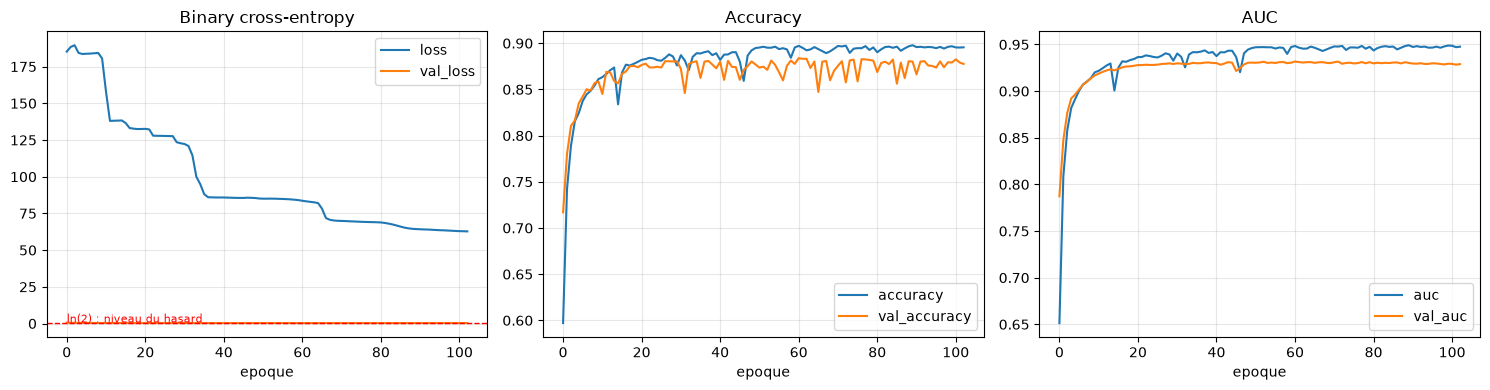

meilleure epoque : 78/103   val_loss=0.3238   val_auc=0.9311


In [15]:
# ================================================================
# COURBES D'APPRENTISSAGE
# ================================================================
import matplotlib.pyplot as plt

h = history.history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, keys, title in [
    (axes[0], ['loss', 'val_loss'], 'Binary cross-entropy'),
    (axes[1], ['accuracy', 'val_accuracy'], 'Accuracy'),
    (axes[2], ['auc', 'val_auc'], 'AUC'),
]:
    for k in keys:
        if k in h:
            ax.plot(h[k], label=k)
    ax.set_xlabel('epoque'); ax.set_title(title); ax.legend(); ax.grid(alpha=.3)
axes[0].axhline(np.log(2), ls='--', c='r', lw=1)
axes[0].annotate('ln(2) : niveau du hasard', (0, np.log(2)), color='r', fontsize=8)
plt.tight_layout(); plt.show()

best = int(np.argmin(h['val_loss']))
print(f"meilleure epoque : {best+1}/{len(h['val_loss'])}"
      f"   val_loss={h['val_loss'][best]:.4f}"
      f"   val_auc={h.get('val_auc', [float('nan')])[best]:.4f}")
if best == 0:
    print("!! La premiere epoque est la meilleure : le modele n'apprend pas.")


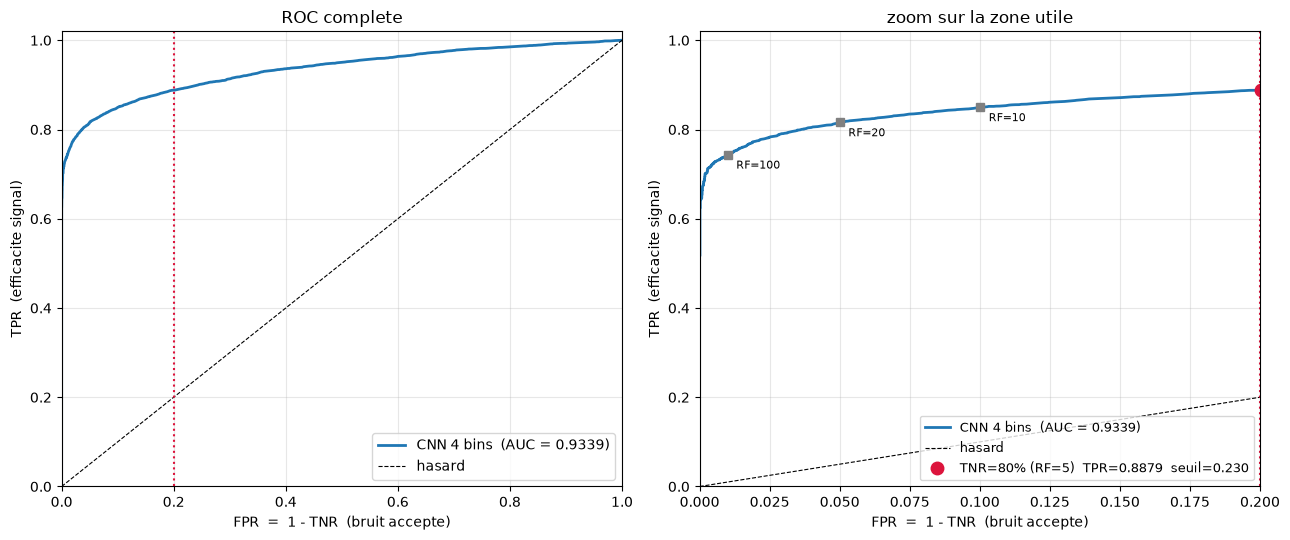

AUC = 0.93391
     TNR     RF     seuil      TPR
  80.00%      5    0.2299   0.8879
  90.00%     10    0.3438   0.8498
  95.00%     20    0.4790   0.8160
  99.00%    100    0.7722   0.7435


In [16]:
# ================================================================
# COURBE ROC
# ================================================================

from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(y_true, y_score, label="CNN", tnr_target=0.80, ax=None):
    y = np.asarray(y_true).ravel() >= 0.5
    s = np.asarray(y_score).ravel()
    fpr, tpr, thr = roc_curve(y, s)
    auc = roc_auc_score(y, s)

    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

    for a, (xmax, titre) in zip(ax, [(1.0, "ROC complete"),
                                     (1 - tnr_target, "zoom sur la zone utile")]):
        a.plot(fpr, tpr, lw=2, label=f"{label}  (AUC = {auc:.4f})")
        a.plot([0, 1], [0, 1], 'k--', lw=0.8, label="hasard")
        a.set_xlim(0, xmax); a.set_ylim(0, 1.02)
        a.set_xlabel("FPR  =  1 - TNR  (bruit accepte)")
        a.set_ylabel("TPR  (efficacite signal)")
        a.set_title(titre); a.grid(alpha=.3)

    # contrainte du systeme : facteur de reduction 5  ->  TNR >= 80 %
    i = np.searchsorted(fpr, 1 - tnr_target)
    for a in ax:
        a.axvline(1 - tnr_target, color='crimson', ls=':', lw=1.5)
    ax[1].plot(fpr[i], tpr[i], 'o', color='crimson', ms=9,
               label=f"TNR={tnr_target:.0%} (RF={1/(1-tnr_target):.0f})  "
                     f"TPR={tpr[i]:.4f}  seuil={thr[i]:.3f}")

    # quelques autres points de fonctionnement
    for t in [0.90, 0.95, 0.99]:
        j = np.searchsorted(fpr, 1 - t)
        ax[1].plot(fpr[j], tpr[j], 's', ms=6, color='grey')
        ax[1].annotate(f"RF={1/(1-t):.0f}", (fpr[j], tpr[j]),
                       textcoords="offset points", xytext=(6, -10), fontsize=8)

    ax[0].legend(loc="lower right")
    ax[1].legend(loc="lower right", fontsize=9)
    plt.tight_layout(); plt.show()

    print(f"AUC = {auc:.5f}")
    print(f"{'TNR':>8} {'RF':>6} {'seuil':>9} {'TPR':>8}")
    for t in [0.80, 0.90, 0.95, 0.99]:
        j = np.searchsorted(fpr, 1 - t)
        print(f"{t:8.2%} {1/(1-t):6.0f} {thr[j]:9.4f} {tpr[j]:8.4f}")
    return fpr, tpr, thr, auc


y_score = np.asarray(model.predict(model_input_test, batch_size=4096, verbose=0)).ravel()
_ = plot_roc(y_test, y_score, label="CNN 4 bins")

In [17]:
REDUCTION_FACTOR = 5.0
TNR_TARGET = 1 - 1 / REDUCTION_FACTOR      # 0.80

def tpr_at_tnr(y_true, y_score, tnr_target=TNR_TARGET):
    y_true  = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()
    neg = y_score[y_true < 0.5]
    pos = y_score[y_true >= 0.5]
    if neg.size == 0 or pos.size == 0:
        return float('nan'), float('nan')
    thr = float(np.quantile(neg, tnr_target))
    return float((pos > thr).mean()), thr

def evaluate(mdl, inputs, y_true, name=""):
    s = np.asarray(mdl.predict(inputs, batch_size=4096, verbose=0)).ravel()
    tpr, thr = tpr_at_tnr(y_true, s)
    auc = roc_auc_score(np.asarray(y_true).ravel() >= 0.5, s)
    print(f"{name:14s} AUC={auc:.4f}   TPR@TNR>={TNR_TARGET:.0%} = {tpr:.4f}   (seuil {thr:.4f})")
    return {"auc": auc, "tpr": tpr, "threshold": thr}

_ = evaluate(model, model_input_val, y_val, "validation")

validation     AUC=0.9312   TPR@TNR>=80% = 0.8841   (seuil 0.2369)


In [18]:
# ================================================================
# BALAYAGE 1 : LEARNING RATE
# ----------------------------------------------------------------
# Les resultats sont ecrits dans DATA_ROOT/sweeps/lr_sweep.csv.
# ================================================================
import gc, json, time
from sklearn.metrics import roc_auc_score
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

SWEEP_DIR = f"{DATA_ROOT}sweeps/"
os.makedirs(SWEEP_DIR, exist_ok=True)

EPOCHS_SWEEP = 40
BATCH_SWEEP  = 1024
SEED         = 0

def build_quantized_model():
    with QuantizerConfigScope(q_type='kif', place='weight',
                              overflow_mode='SAT_SYM', round_mode='RND'):
        with QuantizerConfigScope(q_type='kif', place='datalane',
                                  overflow_mode='WRAP', round_mode='RND'):
            return model_inter_process_CNN(n_channels=N_CHANNELS, verbose=False)

            
def reset_session():
    """keras.backend.clear_session() leve
       AttributeError: module 'keras.src.backend' has no attribute 'backend'
       dans cette version de Keras (bug interne, import circulaire).
       Sur backend JAX il n'est de toute facon pas necessaire a la correction :
       les tableaux sont liberes des que Python lache la reference. On tente,
       on ignore l'echec, et on force le ramasse-miettes."""
    try:
        keras.backend.clear_session()
    except Exception:
        pass
    gc.collect()

def run_one(lr, class_weight=None, epochs=EPOCHS_SWEEP, beta0=BETA0_TP, tag=""):
    reset_session()
    keras.utils.set_random_seed(SEED)
    m = build_quantized_model()
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss=keras.losses.BinaryCrossentropy(),
              metrics=[keras.metrics.BinaryAccuracy(name='accuracy'),
                       keras.metrics.AUC(name='auc')])
    t0 = time.perf_counter()
    hist = m.fit(model_input_train, y_train,
                 epochs=epochs, batch_size=BATCH_SWEEP, verbose=0,
                 validation_data=(model_input_val, y_val), shuffle=True,
                 validation_batch_size=2048, class_weight=class_weight,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                          restore_best_weights=True),
                            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                              patience=5, min_lr=1e-6)])
    dt = time.perf_counter() - t0
    h = hist.history
    best = int(np.argmin(h['val_loss']))
    s = np.asarray(m.predict(model_input_val, batch_size=4096, verbose=0)).ravel()
    tpr, thr = tpr_at_tnr(y_val, s)
    auc = roc_auc_score(np.asarray(y_val).ravel() >= 0.5, s)
    res = dict(tag=tag, lr=lr,
               class_weight=json.dumps(class_weight) if class_weight else "1:1",
               beta0=beta0, epochs_run=len(h['val_loss']), best_epoch=best + 1,
               val_loss=float(h['val_loss'][best]), val_auc=float(auc),
               tpr_at_tnr=float(tpr), threshold=float(thr), seconds=round(dt, 1))
    print(f"  lr={lr:<9.0e} cw={res['class_weight']:<12s} "
          f"best_ep={res['best_epoch']:>3d}/{res['epochs_run']:<3d} "
          f"val_loss={res['val_loss']:.4f}  AUC={auc:.4f}  "
          f"TPR@TNR80={tpr:.4f}   ({dt:.0f}s)")
    del m; gc.collect()
    return res

    
RUN_LR = False

if RUN_LR:
    LR_GRID = [1e-2, 5e-3, 3e-3, 1e-3, 3e-4]
    print(f"Balayage learning rate : {len(LR_GRID)} essais, {EPOCHS_SWEEP} epoques max\n")
    lr_results = [run_one(lr, tag="lr") for lr in LR_GRID]
    
    df_lr = pd.DataFrame(lr_results).sort_values("tpr_at_tnr", ascending=False)
    df_lr.to_csv(SWEEP_DIR + "lr_sweep.csv", index=False)
    print("\n" + df_lr.to_string(index=False))
    BEST_LR = float(df_lr.iloc[0]["lr"])
    print(f"\n=> meilleur learning rate : {BEST_LR:.0e}")


In [19]:
# ================================================================
# BALAYAGE 2 : CLASS_WEIGHT, au meilleur learning rate
# ================================================================
RUN_CLASS_WEIGHT = False

if RUN_CLASS_WEIGHT:

    if not RUN_LR:BEST_LR=LEARNING_RATE
    CW_GRID = [
        {0: 1.0, 1: 1.0},
        {0: 1.0, 1: 2.0},
        {0: 1.0, 1: 3.0},
        {0: 2.0, 1: 1.0},
        {0: 3.0, 1: 1.0},
    ]
    print(f"Balayage class_weight a lr={BEST_LR:.0e} : {len(CW_GRID)} essais\n")
    cw_results = [run_one(BEST_LR, class_weight=cw, tag="cw") for cw in CW_GRID]
    
    df_cw = pd.DataFrame(cw_results).sort_values("tpr_at_tnr", ascending=False)
    df_cw.to_csv(SWEEP_DIR + "class_weight_sweep.csv", index=False)
    print("\n" + df_cw.to_string(index=False))
    print(f"\n=> meilleur class_weight : {df_cw.iloc[0]['class_weight']}")
    print(f"Resultats ecrits dans {SWEEP_DIR}")


In [20]:
y_pred = model.predict(model_input_test,batch_size=1000)
print("y_pred shape: ", np.asarray(y_pred).reshape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step
y_pred shape:  <built-in method reshape of numpy.ndarray object at 0x74f3f45017d0>


In [21]:
def confusion_matrix_indexing(y_pred,y_test,index_test,threshold=0.50):
    cf_matrix = np.zeros((2,2))
    index_list = []
    for i,pred in enumerate(y_pred):
            #print(pred)
            if(pred>=threshold and (y_test[i]>=0.5).any()):
                cf_matrix[1][1] +=1
            if(pred<threshold and (y_test[i]>=0.5).any()):
                cf_matrix[1][0] +=1
            if(pred>=threshold and (y_test[i]<0.5).any()):
                cf_matrix[0][1] +=1
                index_list.append(i)
            if(pred<threshold and (y_test[i]<0.5).any()):
                cf_matrix[0][0] +=1

    return cf_matrix, index_list


def print_performances(cf_matrix):
    true_positive = cf_matrix[1][1]
    true_negative = cf_matrix[0][0]
    false_positive = cf_matrix[0][1]
    false_negative = cf_matrix[1][0]

    purity = true_positive / (true_positive+false_positive)
    recall = true_positive / (true_positive+false_negative)
    accuracy = (true_positive+true_negative) / (true_positive+false_positive+true_negative+false_negative)

    print(f'Purity = {purity}')
    print(f'Recall = {recall}')
    print(f'Accuracy = {accuracy}')
    print(f'TNR = {true_negative/(false_positive+true_negative)}')
    print(f'TPR = {true_positive/(false_negative+true_positive)}')



def confusion_matrix_image(cf_matrix, SAVE=False, data_string="", pdf=False):
    cmn = np.asarray(cf_matrix, dtype=float)
    labels = ['Noise Only', 'Sig+Bckg+Noise']

    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(cmn, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # annotations : texte blanc sur les cases foncees pour rester lisible
    seuil = cmn.max() / 2.0
    for i in range(cmn.shape[0]):
        for j in range(cmn.shape[1]):
            ax.text(j, i, f"{cmn[i, j]:g}", ha="center", va="center",
                    fontsize=14, color="white" if cmn[i, j] > seuil else "black")

    # les graduations doivent exister avant qu'on leur donne des etiquettes
    ax.set_xticks(range(cmn.shape[1]))
    ax.set_yticks(range(cmn.shape[0]))
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_yticklabels(labels, fontsize=14)

    ax.set_xlabel('Predicted labels', fontsize=14)
    ax.set_ylabel('True labels', fontsize=14)
    ax.set_title('Confusion Matrix', fontsize=14)
    plt.tight_layout()

    if SAVE:
        os.makedirs("pdf_images", exist_ok=True)
        ext = "pdf" if pdf else "png"
        plt.savefig(f"pdf_images/keras_cfmatrix_{data_string}.{ext}",
                    dpi=300, bbox_inches='tight')

[[7462.  361.]
 [1515. 6462.]]
1515.0


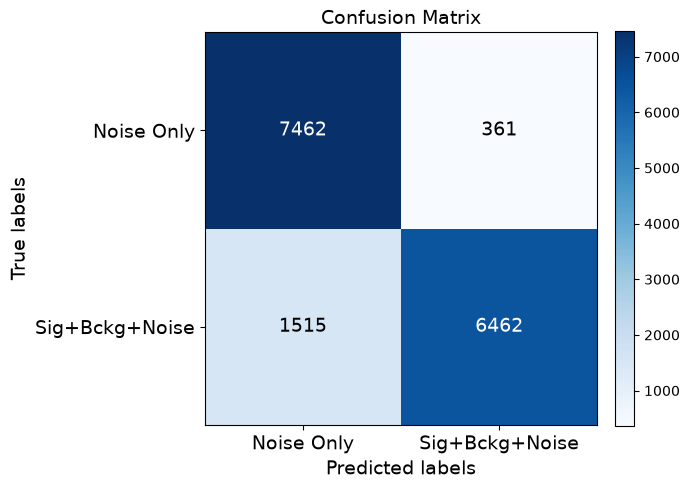

In [22]:
cf_matrix, index_list = confusion_matrix_indexing(y_pred,y_test,index_test,threshold=0.5)
print(cf_matrix)
print(cf_matrix[1][0])

confusion_matrix_image(cf_matrix)

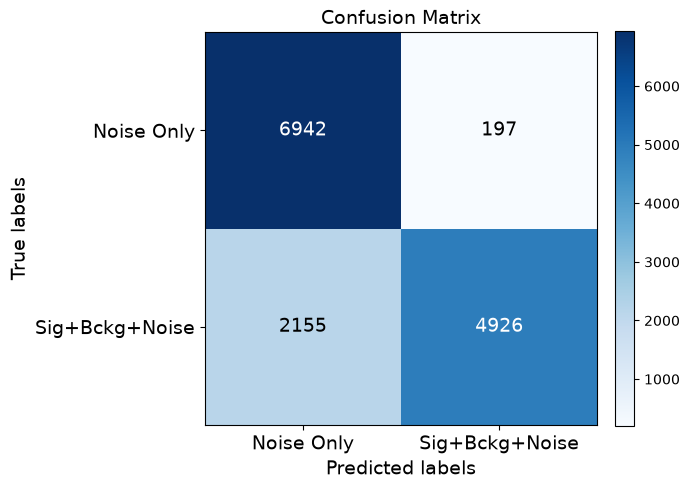

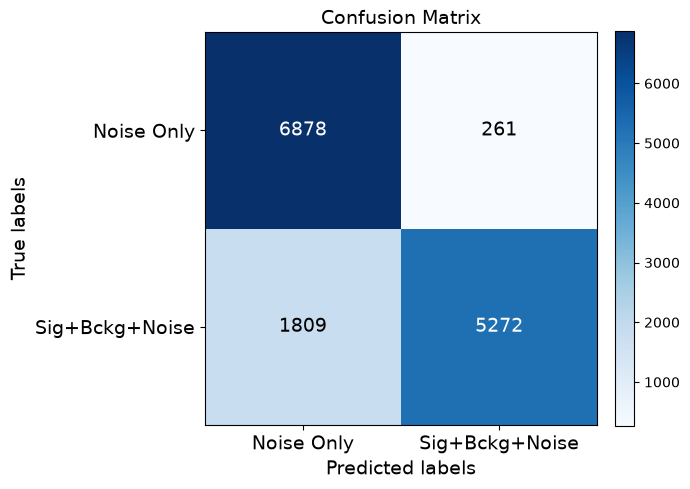

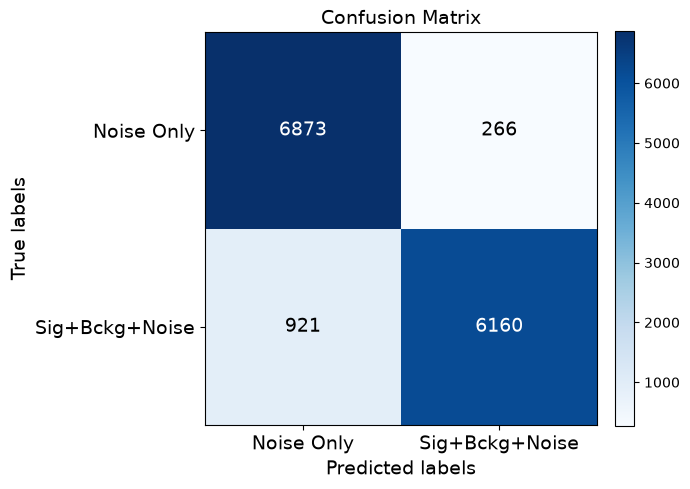

In [53]:
import numpy as np

# --- MLP time-independent : inchangee, c'est la reference -------------
cf_mlp_notime = np.array([[6942,  197],
                          [2155, 4926]], dtype=float)

# --- MLP time-dependent : redimensionnee (etait 1803 / 1797) ----------
cf_mlp_time   = np.array([[6878,  261],
                          [1809, 5272]], dtype=float)

# --- CNN time-dependent : redimensionnee (etait 1800 / 1800) ----------
cf_cnn        = np.array([[6873,  266],
                          [ 921, 6160]], dtype=float)

confusion_matrix_image(cf_mlp_notime)
confusion_matrix_image(cf_mlp_time)
confusion_matrix_image(cf_cnn)

seuil calibre a TNR=80% : 0.23687
seuil calibre sur validation : 0.22850
  TNR sur validation : 0.7899  -> RF = 4.76
  TNR sur test       : 0.7979  -> RF = 4.95
Purity = 0.8175839390792662
Recall = 0.8883038736367055
Accuracy = 0.8435443037974684
TNR = 0.7979036175380289
TPR = 0.8883038736367055
facteur de reduction = 4.9


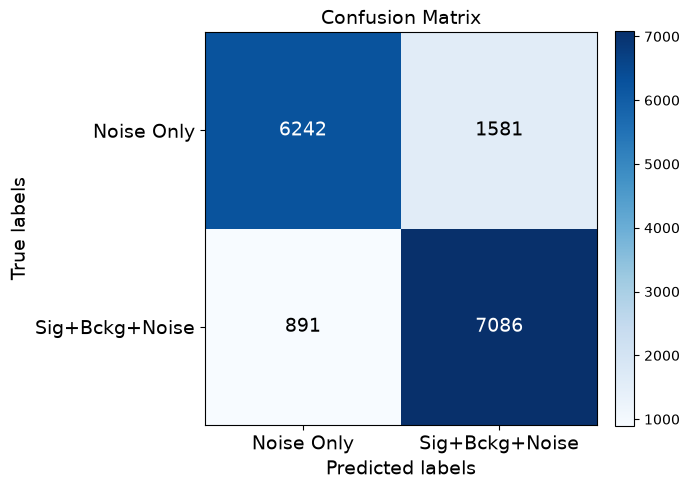

In [51]:
TNR_CIBLE=0.79

def seuil_pour_tnr(y_true, y_score, tnr_cible=0.80):
    """Seuil exact atteignable : le k-ieme score de bruit trie, de sorte que
    rejeter tout ce qui est en dessous garantit TNR >= tnr_cible."""
    y = np.asarray(y_true).ravel() >= 0.5
    s = np.asarray(y_score).ravel()
    bruit = np.sort(s[~y])
    k = int(np.ceil(tnr_cible * len(bruit))) - 1
    return float(bruit[k])


# --- calibration sur la VALIDATION, jamais sur le test ---------------
score_val = np.asarray(model.predict(model_input_val, batch_size=8192, verbose=0)).ravel()
SEUIL = seuil_pour_tnr(y_val, score_val, tnr_cible=0.8)
print(f"seuil calibre a TNR=80% : {SEUIL:.5f}")

s_val  = np.asarray(model.predict(model_input_val,  batch_size=4096, verbose=0)).ravel()
s_test = np.asarray(model.predict(model_input_test, batch_size=4096, verbose=0)).ravel()
yv = np.asarray(y_val).ravel()  >= 0.5
yt = np.asarray(y_test).ravel() >= 0.5

def tnr_obtenu(scores, y, thr):
    return float(np.mean(scores[~y] < thr))

SEUIL = seuil_pour_tnr(y_val, s_val, TNR_CIBLE)
tv, tt = tnr_obtenu(s_val, yv, SEUIL), tnr_obtenu(s_test, yt, SEUIL)
print(f"seuil calibre sur validation : {SEUIL:.5f}")
print(f"  TNR sur validation : {tv:.4f}  -> RF = {1/(1-tv):.2f}")
print(f"  TNR sur test       : {tt:.4f}  -> RF = {1/(1-tt):.2f}")



# --- application sur le test ----------------------------------------
y_pred = np.asarray(model.predict(model_input_test, batch_size=4096, verbose=0)).ravel()
cf, idx = confusion_matrix_indexing(y_pred, y_test, index_test, threshold=SEUIL)
confusion_matrix_image(cf)
print_performances(cf)
print(f"facteur de reduction = {(cf[0][0]+cf[0][1])/cf[0][1]:.1f}")

In [24]:
# ================================================================
# MOYENNE SUR ENSEMBLE DE N MODELES
# ================================================================
RUN_ENSEMBLE = False

if RUN_ENSEMBLE:
    N_SEEDS = 5
    ensemble_preds = []
    for seed in range(N_SEEDS):
        reset_session()
        keras.utils.set_random_seed(seed)
        m = build_quantized_model()
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=BEST_LR),
                  loss=keras.losses.BinaryCrossentropy(),
                  metrics=[keras.metrics.BinaryAccuracy(name='accuracy'),
                           keras.metrics.AUC(name='auc')])
        m.fit(model_input_train, y_train, epochs=200, batch_size=1024,
              validation_data=(model_input_val, y_val), shuffle=True,
              validation_batch_size=2048, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                                       restore_best_weights=True)])
        ensemble_preds.append(np.asarray(
            m.predict(model_input_test, batch_size=4096, verbose=0)).ravel())
        print(f"seed {seed} termine")

    y_pred_ensemble = np.mean(ensemble_preds, axis=0)
    tpr, thr = tpr_at_tnr(y_test, y_pred_ensemble)
    print(f"ensemble : TPR@TNR>={TNR_TARGET:.0%} = {tpr:.4f} (seuil {thr:.4f})")


In [25]:
def values_TPR_TNR(cf_matrix):
    true_negative = cf_matrix[0][0]
    true_positive = cf_matrix[1][1]
    false_negative = cf_matrix[1][0]
    false_positive = cf_matrix[0][1]
    TNR = true_negative/(false_positive+true_negative)
    TPR = true_positive/(false_negative+true_positive)

    return TPR,TNR

In [26]:
# !pip install hls4ml   # deja installe dans l env conda local

import hls4ml


hls4ml.model.optimizer.optimizer.layers = ['Activation']
hls4ml.model.optimizer.optimizer.rounding_mode = 'AP_RND'
hls4ml.model.optimizer.optimizer.saturation_mode = 'AP_SAT'

In [27]:
from collections import Counter

print("nb d'entrees :", len(model_input_train))
print("evenements   :", len(model_input_train[0]))
print("formes       :", Counter(t.shape[1:] for t in model_input_train))

nb d'entrees : 30
evenements   : 126400
formes       : Counter({(21, 3, 3): 18, (17, 4, 3): 12})


In [28]:
for i, t in enumerate(model_input_train):
    print(f"DAM {i:>2} : {t.shape}")

DAM  0 : (126400, 21, 3, 3)
DAM  1 : (126400, 21, 3, 3)
DAM  2 : (126400, 21, 3, 3)
DAM  3 : (126400, 17, 4, 3)
DAM  4 : (126400, 17, 4, 3)
DAM  5 : (126400, 21, 3, 3)
DAM  6 : (126400, 21, 3, 3)
DAM  7 : (126400, 21, 3, 3)
DAM  8 : (126400, 17, 4, 3)
DAM  9 : (126400, 17, 4, 3)
DAM 10 : (126400, 21, 3, 3)
DAM 11 : (126400, 21, 3, 3)
DAM 12 : (126400, 21, 3, 3)
DAM 13 : (126400, 17, 4, 3)
DAM 14 : (126400, 17, 4, 3)
DAM 15 : (126400, 21, 3, 3)
DAM 16 : (126400, 21, 3, 3)
DAM 17 : (126400, 21, 3, 3)
DAM 18 : (126400, 17, 4, 3)
DAM 19 : (126400, 17, 4, 3)
DAM 20 : (126400, 21, 3, 3)
DAM 21 : (126400, 21, 3, 3)
DAM 22 : (126400, 21, 3, 3)
DAM 23 : (126400, 17, 4, 3)
DAM 24 : (126400, 17, 4, 3)
DAM 25 : (126400, 21, 3, 3)
DAM 26 : (126400, 21, 3, 3)
DAM 27 : (126400, 21, 3, 3)
DAM 28 : (126400, 17, 4, 3)
DAM 29 : (126400, 17, 4, 3)


In [29]:
################  DECOUPAGE DU MODELE POUR hls4ml  #############################
qmodel = model

damI, sector_mlp = [], []
damI_output_train, damI_output_test = [], []
sector_input_train, sector_input_test = [], []
sector_output_train, sector_output_test = [], []

# ---------------------------------------------------------------- DAM --------
if PARTAGE_POIDS:
    sous = {l.name: l for l in qmodel.layers if isinstance(l, keras.Model)}
    manquants = [f"dam_s{n}" for n in range(5) if f"dam_s{n}" not in sous]
    assert not manquants, f"sous-modeles DAM introuvables dans qmodel : {manquants}"
    damI = [sous[f"dam_s{n}"] for n in range(5)]
    IDX_DAM = lambda i: i % 5
else:
    IDX_DAM = lambda i: i
    damI = [Model(inputs=qmodel.input[idx],
                  outputs=qmodel.get_layer(f'fc_{idx}').output) for idx in range(30)]

print(f"{len(damI)} modele(s) DAM distinct(s)")

for idx in range(30):                          # 30 positions physiques
    m = damI[IDX_DAM(idx)]
    damI_output_train.append(m.predict(model_input_train[idx], batch_size=4096, verbose=0))
    damI_output_test.append( m.predict(model_input_test[idx],  batch_size=4096, verbose=0))

for sec in range(6):
    sector_input_train.append(np.concatenate(damI_output_train[sec*5:sec*5+5], axis=-1))
    sector_input_test.append( np.concatenate(damI_output_test[sec*5:sec*5+5],  axis=-1))
print("entree secteur :", sector_input_train[0].shape, sector_input_test[0].shape)

# ------------------------------------------------------------- SECTEUR -------
if PARTAGE_POIDS:
    assert not BN_SECTEUR, ("une BatchNorm par secteur casse le partage du "
                            "sous-modele secteur : mets BN_SECTEUR=False")
    sec_in = Input(shape=(40,), name='sector_input')
    h = qmodel.get_layer('sector_fc4_shared')(sec_in)
    h = qmodel.get_layer('sector_fc5_shared')(h)
    sec_out = qmodel.get_layer('sector_fc6_shared')(h)
    sector_mlp = [Model(sec_in, sec_out, name='sector_shared')]
    IDX_SEC = lambda j: 0
else:
    IDX_SEC = lambda j: j
    dernier = 'sector_bn_' if BN_SECTEUR else 'sector_fc6_'
    for sec in range(6):
        sector_mlp.append(Model(inputs=qmodel.get_layer(f'concatenate_{sec}').output,
                                outputs=qmodel.get_layer(f'{dernier}{sec}').output))

print(f"{len(sector_mlp)} modele(s) secteur distinct(s)")

for sec in range(6):
    m = sector_mlp[IDX_SEC(sec)]
    sector_output_train.append(m.predict(sector_input_train[sec], batch_size=4096, verbose=0))
    sector_output_test.append( m.predict(sector_input_test[sec],  batch_size=4096, verbose=0))

last_model_input_train = np.concatenate(sector_output_train, axis=-1)
last_model_input_test  = np.concatenate(sector_output_test,  axis=-1)
print("entree agregation :", last_model_input_train.shape, last_model_input_test.shape)

# ---------------------------------------------------------- AGREGATION -------
agg_in = Input(shape=(24,), name='agg_input')
h = agg_in
if AGG_HIDDEN:
    h = qmodel.get_layer('agg_fc1')(h)
last_model = Model(agg_in, qmodel.get_layer('fc8_damII')(h), name='aggregation')

last_predict_train = last_model.predict(last_model_input_train, batch_size=4096, verbose=0)
last_predict_test  = last_model.predict(last_model_input_test,  batch_size=4096, verbose=0)

# --- controle : la chaine reconstruite doit reproduire le modele complet ------
ref = np.asarray(qmodel.predict(model_input_test, batch_size=4096, verbose=0)).ravel()
rec = np.asarray(last_predict_test).ravel()
print(f"\nchaine reconstruite vs modele complet : ecart max "
      f"{np.abs(ref - rec).max():.2e}   "
      f"{'OK' if np.allclose(ref, rec, atol=1e-4) else 'INCOHERENT'}")

30 modele(s) DAM distinct(s)
entree secteur : (126400, 40) (15800, 40)
6 modele(s) secteur distinct(s)
entree agregation : (126400, 24) (15800, 24)

chaine reconstruite vs modele complet : ecart max 0.00e+00   OK


In [30]:
hls4ml.model.optimizer.optimizer.layers = ['Activation']
hls4ml.model.optimizer.optimizer.rounding_mode = 'AP_RND'
hls4ml.model.optimizer.optimizer.saturation_mode = 'AP_SAT'

# Note that without the above instruction the hls accuracy drop to 25% i.e. random choice among 4 classes

#   hls_config     = hls4ml.utils.config_from_keras_model(model, granularity='model')
#   hls_config     = hls4ml.utils.config_from_keras_model(model, granularity='name')

reuse_factor=1
hls_config_sector = []
for i in range(len(sector_mlp)):
    hls_config_sector.append(hls4ml.utils.config_from_keras_model(sector_mlp[i], granularity='name',default_precision='fixed<-1,0>',default_reuse_factor=reuse_factor))
    hls_config_sector[i]['Model']['Strategy'] = 'distributed_arithmetic'
    #hls_config_sector[i]['Model']['PipelineStyle']='pipeline'
    hls_config_sector[i]['Model']['PipelineInterval']='1'
    hls_config_sector[i]['Model']['BRAM']='True'
    hls_config_sector[i]['Model']['PipelineStyle']='dataflow'
#hls_config_sector['Model']["BramFactor"] = 1

hls_config_dam = []
for i in range(len(damI)):
    hls_config_dam.append(hls4ml.utils.config_from_keras_model(damI[i], granularity='name',default_precision='fixed<-1,0>'
                                                      ,default_reuse_factor=reuse_factor))
    hls_config_dam[i]['Model']['Strategy'] = 'distributed_arithmetic'
    hls_config_dam[i]['Model']['PipelineStyle']='pipeline'
    hls_config_dam[i]['Model']['PipelineInterval']='1'
    hls_config_dam[i]['Model']['BRAM']='True'
    hls_config_dam[i]['Model']['PipelineStyle']='dataflow'
#hls_config_sector['Model']["BramFactor"] = 1

hls_config_last_model    = hls4ml.utils.config_from_keras_model(last_model, granularity='name',default_precision='fixed<-1,0>'
                                                      ,default_reuse_factor=reuse_factor)
hls_config_last_model['Model']['Strategy'] = 'distributed_arithmetic'
hls_config_last_model['Model']['PipelineStyle']='dataflow'
#hls_config_last_model['Model']['PipelineStyle']='pipeline'
hls_config_last_model['Model']['PipelineInterval']='1'
hls_config_last_model['Model']['BRAM']='True'
#hls_config_sector['Model']["BramFactor"] = 1

In [31]:
hls_model_dam = []

# !pip install da4ml   # deja installe dans l env conda local
import da4ml

for i in range(len(damI)):
    print("####### DAM MODEL {num} ###### \n".format(num=i))
    hls_model_dam.append(hls4ml.converters.convert_from_keras_model( damI[i],  hls_config   = hls_config_dam[i],
                                    output_dir   = "hw_dam_prova_{num}".format(num=i),
                                     part    = "xcvm1802-vsva2197-1MP-e-S",#"xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_DAM{num}".format(num=i),
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis'))
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
    hls_model_dam[i].compile()

####### DAM MODEL 0 ###### 

####### DAM MODEL 1 ###### 

####### DAM MODEL 2 ###### 

####### DAM MODEL 3 ###### 

####### DAM MODEL 4 ###### 

####### DAM MODEL 5 ###### 

####### DAM MODEL 6 ###### 

####### DAM MODEL 7 ###### 

####### DAM MODEL 8 ###### 

####### DAM MODEL 9 ###### 

####### DAM MODEL 10 ###### 

####### DAM MODEL 11 ###### 

####### DAM MODEL 12 ###### 

####### DAM MODEL 13 ###### 

####### DAM MODEL 14 ###### 

####### DAM MODEL 15 ###### 

####### DAM MODEL 16 ###### 

####### DAM MODEL 17 ###### 

####### DAM MODEL 18 ###### 

####### DAM MODEL 19 ###### 

####### DAM MODEL 20 ###### 

####### DAM MODEL 21 ###### 

####### DAM MODEL 22 ###### 

####### DAM MODEL 23 ###### 

####### DAM MODEL 24 ###### 

####### DAM MODEL 25 ###### 

####### DAM MODEL 26 ###### 

####### DAM MODEL 27 ###### 

####### DAM MODEL 28 ###### 

####### DAM MODEL 29 ###### 



In [32]:
#import os
#os.environ['PATH'] = '/opt/Xilinx/Vivado/2020.1/bin:' + os.environ['PATH']
#os.environ['PATH'] = '/opt/Xilinx/Vitis_HLS/2022.1/bin:' + os.environ['PATH']
#print(os.environ['PATH'])

In [33]:
#hls_model_dam[0].build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True)

In [34]:
#hls4ml.report.read_vivado_report("hw_dam_0")

In [35]:
hls_model_sector = []

for i in range(len(sector_mlp)):
    print("####### SECTOR MODEL {num} ###### \n".format(num=i))
    hls_model_sector.append(hls4ml.converters.convert_from_keras_model( sector_mlp[i],  hls_config   = hls_config_sector[i],
                                    output_dir   = "hw_sector_prova_{num}".format(num=i),
                                     part    = "xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_Sec{num}".format(num=i),
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis'))
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
    hls_model_sector[i].compile()


####### SECTOR MODEL 0 ###### 

####### SECTOR MODEL 1 ###### 

####### SECTOR MODEL 2 ###### 

####### SECTOR MODEL 3 ###### 

####### SECTOR MODEL 4 ###### 

####### SECTOR MODEL 5 ###### 



In [36]:
#hls_model_sector[0].build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True, fifo_opt=True)

In [37]:
#hls4ml.report.read_vivado_report("hw_sector_0")

In [38]:
hls_mlp_last_model = []


print("####### LAST MLP MODEL {num} ###### \n".format(num=i))
hls_mlp_last_model = hls4ml.converters.convert_from_keras_model( last_model,  hls_config   = hls_config_last_model,
                                    output_dir   = "hw_last_model_prova_{num}".format(num=i),
                                     part    = "xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_last",
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis')
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
hls_mlp_last_model.compile()


####### LAST MLP MODEL 5 ###### 



In [39]:
#hls_mlp_last_model.build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True, fifo_opt=True)

In [40]:
#hls4ml.report.read_vivado_report("hw_last_model_prova_0")

In [41]:

hls_output_dam = []
hls4ml_output_sector = []
hls4ml_sector_input = []

hls_output_dam = [hls_model_dam[IDX_DAM(i)].predict(
                      np.ascontiguousarray(model_input_test[i]).astype(np.float32))
                  for i in range(30)]

for j in range(6):
    xs = np.concatenate(hls_output_dam[j*5:j*5+5], axis=1)
    hls4ml_output_sector.append(hls_model_sector[IDX_SEC(j)].predict(
        np.ascontiguousarray(xs).astype(np.float32)))

for i in range(len(damI)):
    print("####### DAM MODEL {num} ###### \n".format(num=i))
    hls_output_dam.append(hls_model_dam[i].predict(np.ascontiguousarray(model_input_test[i]).astype(np.float32)))


print(np.asarray(hls_output_dam).shape)
for j in range(len(sector_mlp)):
    print("####### SECTOR MODEL {num} ###### \n".format(num=j))
    sector_input = np.concatenate((hls_output_dam[j*5],
                                   hls_output_dam[j*5+1],
                                   hls_output_dam[j*5+2],
                                   hls_output_dam[j*5+3],
                                   hls_output_dam[j*5+4],
                                  ), axis=1)
    hls4ml_sector_input.append(sector_input)
    print(np.asarray(hls4ml_sector_input).shape)
    hls4ml_output_sector.append(hls_model_sector[j].predict(hls4ml_sector_input[j]))

print(np.asarray(hls4ml_output_sector).shape)

aggregate_mlp_input = np.concatenate((hls4ml_output_sector[0],
                                   hls4ml_output_sector[1],
                                   hls4ml_output_sector[2],
                                   hls4ml_output_sector[3],
                                   hls4ml_output_sector[4],
                                   hls4ml_output_sector[5],
                                  ), axis=1)

print("####### AGGREGATE MLP MODEL ###### \n")
print(np.asarray(aggregate_mlp_input).shape)
hls4ml_pred = hls_mlp_last_model.predict(np.ascontiguousarray(aggregate_mlp_input))

####### DAM MODEL 0 ###### 

####### DAM MODEL 1 ###### 

####### DAM MODEL 2 ###### 

####### DAM MODEL 3 ###### 

####### DAM MODEL 4 ###### 

####### DAM MODEL 5 ###### 

####### DAM MODEL 6 ###### 

####### DAM MODEL 7 ###### 

####### DAM MODEL 8 ###### 

####### DAM MODEL 9 ###### 

####### DAM MODEL 10 ###### 

####### DAM MODEL 11 ###### 

####### DAM MODEL 12 ###### 

####### DAM MODEL 13 ###### 

####### DAM MODEL 14 ###### 

####### DAM MODEL 15 ###### 

####### DAM MODEL 16 ###### 

####### DAM MODEL 17 ###### 

####### DAM MODEL 18 ###### 

####### DAM MODEL 19 ###### 

####### DAM MODEL 20 ###### 

####### DAM MODEL 21 ###### 

####### DAM MODEL 22 ###### 

####### DAM MODEL 23 ###### 

####### DAM MODEL 24 ###### 

####### DAM MODEL 25 ###### 

####### DAM MODEL 26 ###### 

####### DAM MODEL 27 ###### 

####### DAM MODEL 28 ###### 

####### DAM MODEL 29 ###### 

(60, 15800, 8)
####### SECTOR MODEL 0 ###### 

(1, 15800, 40)
####### SECTOR MODEL 1 ###### 

(2, 15800, 40)
#

In [42]:

# Test for mismatches
# HGQ2 and hls4ml should produce the same output, up to machine precision
# Notice that due to the quantization, internal mismatches may be amplified, but the vast majority of the output should match

keras_pred = model.predict(model_input_test)

print(f"{np.sum((keras_pred>0.5) != (hls4ml_pred>0.5))} / {np.prod(keras_pred.shape)} value mismatches")

494/494 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step
8 / 15800 value mismatches


In [43]:
hls4ml_cf_matrix, hls4ml_index_list = confusion_matrix_indexing(hls4ml_pred,y_test,index_test,threshold=0.5)
print(hls4ml_cf_matrix)

[[7462.  361.]
 [1515. 6462.]]


Purity = 0.9470907225560604
Recall = 0.8100789770590447
Accuracy = 0.8812658227848101
TNR = 0.9538540201968554
TPR = 0.8100789770590447


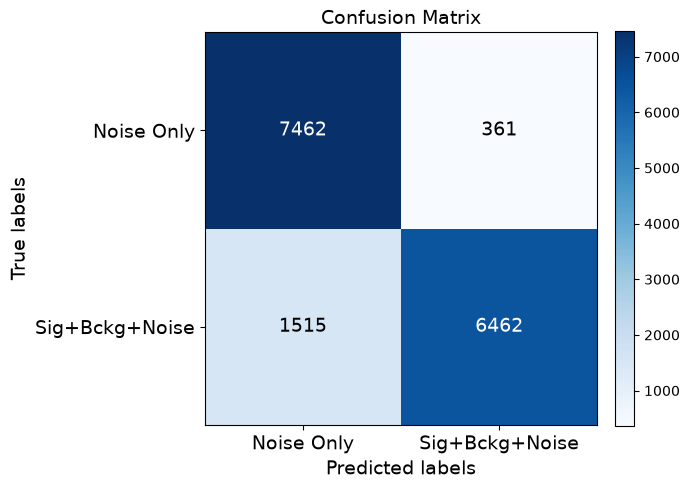

In [44]:
confusion_matrix_image(hls4ml_cf_matrix)
print_performances(hls4ml_cf_matrix)

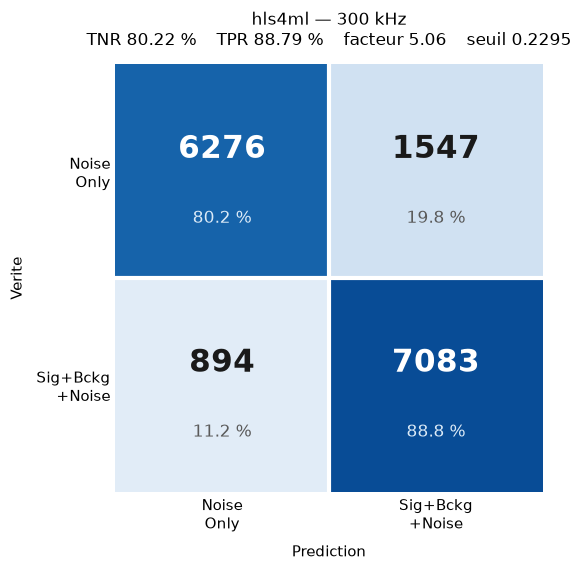

In [45]:
# ================================================================
# MATRICE DE CONFUSION hls4ml AU POINT TNR = 80 %
# ================================================================
s = np.asarray(hls4ml_pred).ravel()
y = np.asarray(y_test).ravel() >= 0.5

# seuil qui place exactement 80 % du bruit en dessous
seuil = float(np.sort(s[~y])[int(np.ceil(0.80 * (~y).sum())) - 1])

cf = np.zeros((2, 2))
pos = s > seuil
cf[0, 0] = np.count_nonzero(~pos & ~y)   # vrai negatif
cf[0, 1] = np.count_nonzero( pos & ~y)   # faux positif
cf[1, 0] = np.count_nonzero(~pos &  y)   # faux negatif
cf[1, 1] = np.count_nonzero( pos &  y)   # vrai positif

pct = 100 * cf / cf.sum(axis=1, keepdims=True)
tnr, tpr = pct[0, 0] / 100, pct[1, 1] / 100

fig, ax = plt.subplots(figsize=(6.4, 5.8))
ax.imshow(pct, cmap='Blues', vmin=0, vmax=100)

for i in range(2):
    for j in range(2):
        clair = pct[i, j] <= 55
        ax.text(j, i - 0.10, f"{cf[i, j]:.0f}", ha='center', va='center',
                fontsize=22, fontweight='bold',
                color='#1a1a1a' if clair else 'white')
        ax.text(j, i + 0.22, f"{pct[i, j]:.1f} %", ha='center', va='center',
                fontsize=12, color='#5a5a5a' if clair else '#dbeaf7')

labels = ['Noise\nOnly', 'Sig+Bckg\n+Noise']
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Prediction", fontsize=11, labelpad=8)
ax.set_ylabel("Verite", fontsize=11, labelpad=8)
ax.set_title(f"hls4ml — {FREQ} kHz\n"
             f"TNR {100*tnr:.2f} %    TPR {100*tpr:.2f} %    "
             f"facteur {1/(1-tnr):.2f}    seuil {seuil:.4f}",
             fontsize=12, pad=14)
ax.set_xticks([0.5], minor=True); ax.set_yticks([0.5], minor=True)
ax.grid(which='minor', color='white', linewidth=3)
ax.tick_params(which='minor', length=0); ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)

plt.tight_layout()
plt.show()

In [46]:
# ================================================================
# CHAINE DE PREDICTION hls4ml
# 30 positions physiques rejouees avec les len(damI) modeles compiles,
# 6 secteurs rejoues avec les len(sector_mlp) MLP compiles.
# ================================================================
N_EV = len(model_input_test[0])

def _2d(a):
    """hls4ml renvoie parfois une sortie aplatie ; on force (N, k)."""
    return np.asarray(a).reshape(N_EV, -1)

# ---------------------------------------------------------------- DAM --------
hls_output_dam = [
    _2d(hls_model_dam[IDX_DAM(i)].predict(
        np.ascontiguousarray(model_input_test[i]).astype(np.float32)))
    for i in range(30)
]
assert len(hls_output_dam) == 30
print("sortie DAM      :", len(hls_output_dam), "x", hls_output_dam[0].shape)

# ------------------------------------------------------------- SECTEUR -------
hls4ml_sector_input, hls4ml_output_sector = [], []
for j in range(6):
    xs = np.concatenate(hls_output_dam[j*5:j*5+5], axis=1)          # (N, 40)
    hls4ml_sector_input.append(xs)
    hls4ml_output_sector.append(
        _2d(hls_model_sector[IDX_SEC(j)].predict(
            np.ascontiguousarray(xs).astype(np.float32))))
assert len(hls4ml_output_sector) == 6
print("sortie secteur  :", len(hls4ml_output_sector), "x", hls4ml_output_sector[0].shape)

# ---------------------------------------------------------- AGREGATION -------
aggregate_mlp_input = np.concatenate(hls4ml_output_sector, axis=1)  # (N, 24)
print("entree agregation :", aggregate_mlp_input.shape)
assert aggregate_mlp_input.shape[1] == 24

hls4ml_pred = _2d(hls_mlp_last_model.predict(
    np.ascontiguousarray(aggregate_mlp_input).astype(np.float32)))
print("sortie finale   :", hls4ml_pred.shape)

sortie DAM      : 30 x (15800, 8)
sortie secteur  : 6 x (15800, 4)
entree agregation : (15800, 24)
sortie finale   : (15800, 1)


In [47]:
WRITE_OUTPUT_DATA = False

In [48]:
if(WRITE_OUTPUT_DATA):
    import os

    # cartella output per i csv di noise
    OUTDIR = "intermediate_output_txt"
    os.makedirs(OUTDIR, exist_ok=True)

    N_DUMP = 1000                       # None = tout le jeu (lis l'avertissement plus bas)
    MARK   = '\n### OUTPUT DATA ###\n'

    def to_2d(a, n=N_DUMP):
        """(N, 21, 3, 4) -> (n, 252)  |  (N, 17, 4, 4) -> (n, 272)
        Ordre C : lignes, colonnes, canaux — exactement l'ordre memoire
        qu'attend le testbench hls4ml en io_parallel."""
        a = np.asarray(a)
        if n is not None:
            a = a[:n]
        return np.ascontiguousarray(a).reshape(len(a), -1)
    
    for i in range(30):
        with open('intermediate_output_txt/damI_input_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, model_input_train[i])
        with open('intermediate_output_txt/damI_input_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, model_input_test[i])
        with open('intermediate_output_txt/damI_output_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, damI_output_train[i])
        with open('intermediate_output_txt/damI_output_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, damI_output_test[i])

         

        np.savetxt(f"{OUTDIR}/damI_input_train_{i}.txt", to_2d(model_input_train[i]),
                   fmt='%.16e', delimiter='\n', newline=MARK)
        np.savetxt(f"{OUTDIR}/damI_input_test_{i}.txt",  to_2d(model_input_test[i]),
                   fmt='%.16e', delimiter='\n', newline=MARK)
        np.savetxt(f"{OUTDIR}/damI_output_train_{i}.txt", to_2d(damI_output_train[i]),
                   fmt='%.16e', delimiter='\n', newline=MARK)
        np.savetxt(f"{OUTDIR}/damI_output_test_{i}.txt",  to_2d(damI_output_test[i]),
                   fmt='%.16e', delimiter='\n', newline=MARK)
        
    for i in range(6):
        with open('intermediate_output_txt/sector_input_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_input_train[i])
        with open('intermediate_output_txt/sector_input_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_input_test[i])
        with open('intermediate_output_txt/sector_output_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_output_train[i])
        with open('intermediate_output_txt/sector_output_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_output_test[i])

        np.savetxt("intermediate_output_txt/sector_input_train_{num}.txt".format(num=i), sector_input_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_input_test_{num}.txt".format(num=i), sector_input_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_output_train_{num}.txt".format(num=i), sector_output_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_output_test_{num}.txt".format(num=i), sector_output_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)



    np.savetxt("intermediate_output_txt/last_model_input_train.txt",last_model_input_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_model_input_test.txt", last_model_input_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_predict_train.txt", last_predict_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_predict_test.txt", last_predict_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/y_train.txt", y_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/y_test.txt", y_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)